In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [10]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# # Calculate potential vorticity
# df_ST = calc_pv(df_ST)

In [11]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 10

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [12]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']
# features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Pv']

In [13]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:956: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [14]:
# Do BIC and AIC calculation for different number of clusters and for 10 different seeds
all_scores = {}
all_aic_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds):
    bic_scores = [] 
    aic_scores = []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_sampled[features])
        bic_scores.append(gmm.bic(df_sampled[features]))
        aic_scores.append(gmm.aic(df_sampled[features]))

    all_scores[i] = bic_scores
    all_aic_scores[i] = aic_scores

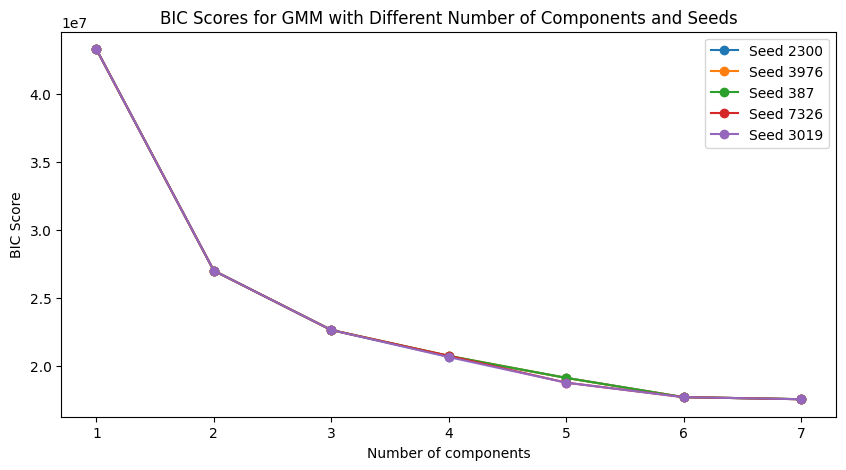

In [15]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

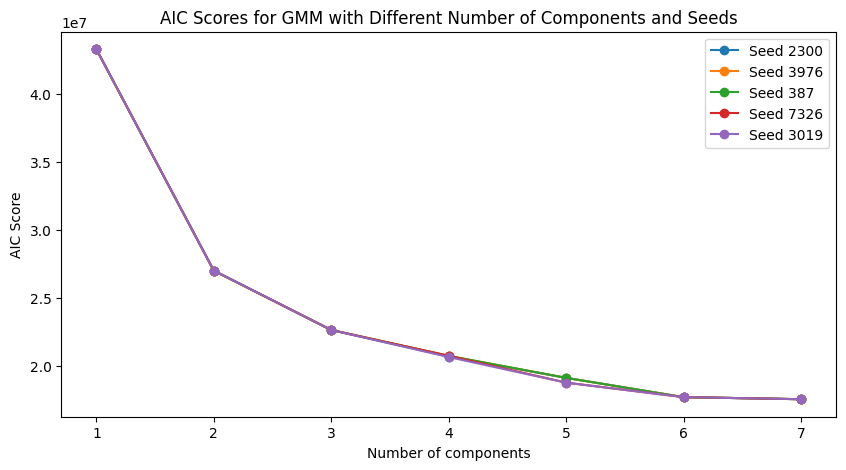

In [16]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(n_components_range, all_aic_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('AIC Score')
plt.title('AIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [17]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [18]:
gmm_0 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels_0 = gmm_0.fit_predict(df_sampled[features])

In [19]:
df_sampled['gmm_label_6'] = labels_0

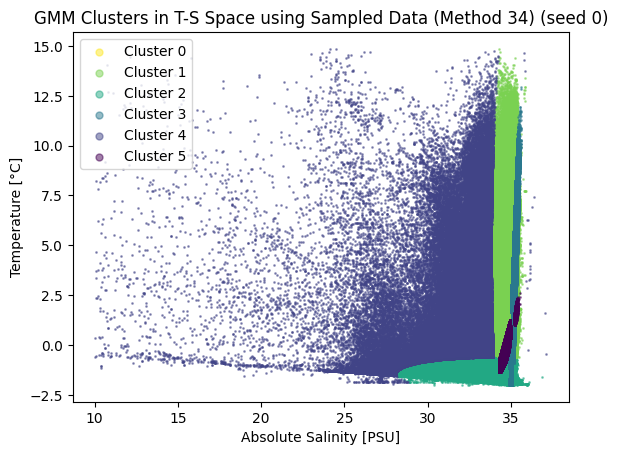

In [20]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:626: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



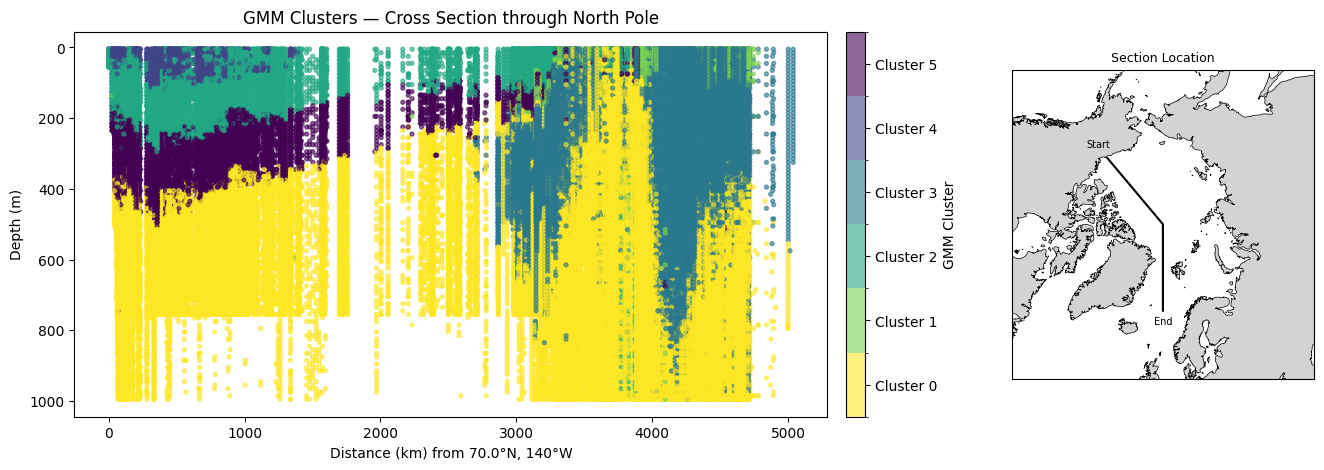

In [24]:
cross_sec_lon(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [22]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_0.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:859: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



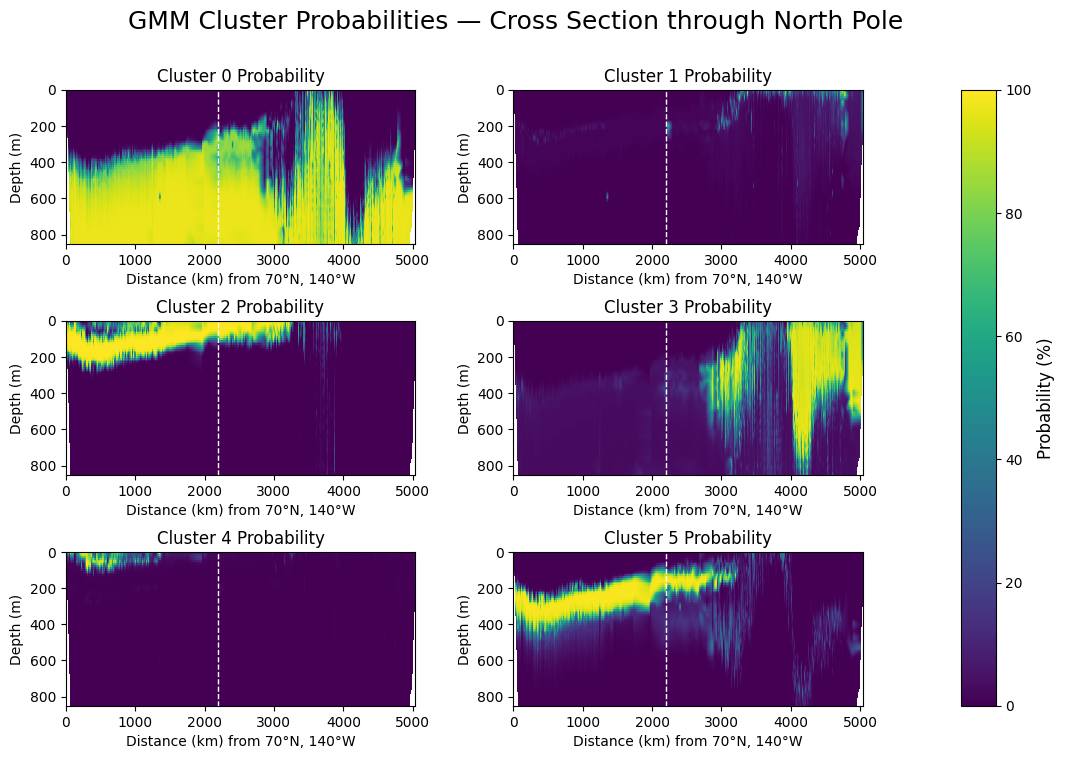

In [23]:
cross_sec_lon_prob2(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [25]:
gmms = []
labels = [] 
for i,seed in enumerate(seeds):
    gmm = GaussianMixture(
        n_components=n_clusters,          # number of clusters
        covariance_type='full',  # full cov matrix has more flexibility
        random_state=seed)
    gmm.fit(df_sampled[features])
    gmms.append(gmm)
    labels.append(gmm.predict(df_sampled[features]))

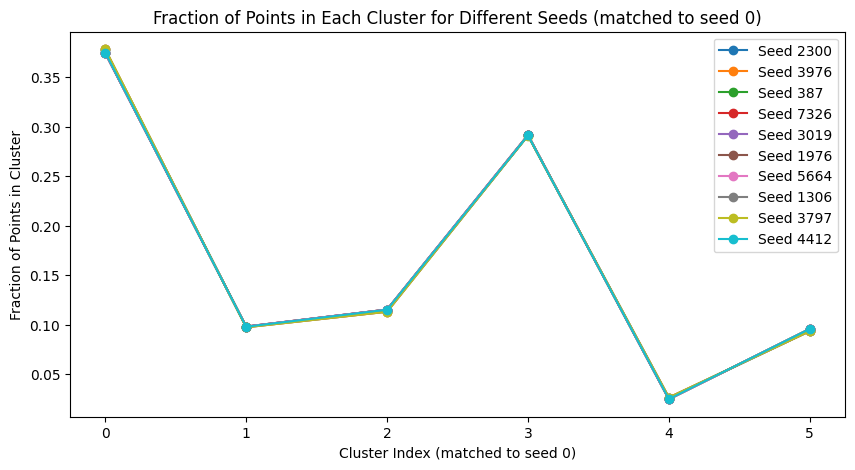

In [27]:
# Preprocess for comparrison of cluster labels across different seeds
# Clusters with similar mean T and S should be matched across different seeds
cluster_means = []
for i in range(ensemble_size):
    means = gmms[i].means_
    cluster_means.append(means)

# Match clusters across different seeds based on closest mean T and S
matched_labels = []
for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.zeros(n_clusters, dtype=int)
    for j in range(n_clusters):
        mean_T = means[j, 0]
        mean_S = means[j, 1]
        min_dist = np.inf
        match = -1
        for k in range(n_clusters):
            dist = np.sqrt((mean_T - cluster_means[0][k, 0])**2 + (mean_S - cluster_means[0][k, 1])**2)
            if dist < min_dist:
                min_dist = dist
                match = k
        matched[j] = match
    matched_labels.append(matched)

# Now matched_labels[i][j] gives the index of the cluster in seed 0 that matches cluster j in seed i
# Calculate the fraction of points in each cluster for each seed
cluster_fractions = []
for i in range(ensemble_size):
    matched = matched_labels[i]
    labels_i = labels[i]
    fractions = np.zeros(n_clusters)
    for j in range(n_clusters):
        cluster_j = np.where(labels_i == j)[0]
        matched_j = matched[j]
        fractions[matched_j] += len(cluster_j) / len(df_sampled)
    cluster_fractions.append(fractions)

# Plot the cluster fractions for each seed
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(range(n_clusters), cluster_fractions[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Cluster Index (matched to seed 0)') 
plt.ylabel('Fraction of Points in Cluster')
plt.title('Fraction of Points in Each Cluster for Different Seeds (matched to seed 0)')
plt.legend()
plt.show()  

In [29]:
# Use matched clusters to calculate variance between ensemble members for each cluster
cluster_variances = []
for j in range(n_clusters):
    cluster_j_points = []
    for i in range(ensemble_size):
        matched = matched_labels[i]
        cluster_j = np.where(labels[i] == np.where(matched == j)[0][0])[0]
        cluster_j_points.append(df_sampled.iloc[cluster_j][features].values)
    #cluster_j_points = np.array(cluster_j_points)  # shape (ensemble_size, n_points_in_cluster, n_features)
    variance = np.var(cluster_j_points, axis=0)  # variance across ensemble members
    cluster_variances.append(variance)

# Plot variance for each cluster
plt.figure(figsize=(10,5))
for j in range(n_clusters):
    plt.plot(features, cluster_variances[j], label=f'Cluster {j}', marker='o')
plt.xlabel('Feature')
plt.ylabel('Variance Across Ensemble Members')
plt.title('Variance of Cluster Points Across Ensemble Members for Each Cluster')
plt.legend()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.